In [6]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [7]:
%%cython

# =========================================================================
# PART 1: C LIBRARY IMPORTS AND GLOBAL DEFINITIONS (Largely Unchanged)
# =========================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

# Import Python libraries needed for the LLM part
import time
import json
import ollama
import numpy as np
import hashlib
from collections import defaultdict

# Constants for the enhanced algorithm
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5  # Default value, can be overridden by heuristics
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05  # Default value, can be overridden by heuristics
cdef int alpha = 10
cdef int paretoIni = 28000

# Data structures (MODIFIED to track more info)
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items
    int age
    int improvement_count
    int llm_enhanced
    int last_improvement_iteration # NEW: Track when it was last improved

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Global variables for the problem instance (unchanged)
cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# =========================================================================
# PART 2: CORE CYTHON HELPER FUNCTIONS (UNCHANGED)
# =========================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.age = 0
    p_ind.improvement_count = 0
    p_ind.llm_enhanced = 0
    p_ind.last_improvement_iteration = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    p_ind.age = i.age
    p_ind.improvement_count = i.improvement_count
    p_ind.llm_enhanced = i.llm_enhanced
    p_ind.last_improvement_iteration = i.last_improvement_iteration
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# =========================================================================
# PART 3: PROBLEM LOADING AND EVALUATION FUNCTIONS (UNCHANGED)
# =========================================================================

def loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

def read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

# =========================================================================
# PART 4: LIBRARY OF LOCAL SEARCH HEURISTICS (NEW IN V5)
# =========================================================================

cdef void local_search_random_swap(pop *SP, pop *Sarchive, int size):
    """Heuristic 1: The original random swap and add strategy. Good for exploration."""
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    free(remplace)

cdef void local_search_best_item_removal(pop *SP, pop *Sarchive, int size):
    """Heuristic 2: Intelligently removes the worst item before adding. Good for exploitation."""
    cdef ind *x
    cdef int i, j, r, k, l, sol, mino, maxp, consistant, feasible, tv
    cdef double worst_ratio, current_ratio
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    # Find the worst item to remove
                    mino = -1
                    worst_ratio = 1e9
                    for k in range(ni):
                        if x.Items[k] == 1:
                            current_ratio = 0
                            for r in range(nf):
                                if weights[r][k] > 0:
                                    current_ratio += profits[r][k] / weights[r][k]
                            current_ratio /= nf
                            if current_ratio < worst_ratio:
                                worst_ratio = current_ratio
                                mino = k
                    
                    if mino != -1:
                        x.Items[mino] = 0
                        x.nombr -= 1
                        x.nombr_nonpris += 1
                        for r in range(nf):
                            x.capa[r] -= weights[r][mino]
                            x.f[r] -= profits[r][mino]

                        # Try to add the best possible item
                        maxp = -1
                        best_ratio = -1
                        for k in range(ni):
                            if x.Items[k] == 0:
                                consistant = 1
                                for r in range(nf):
                                    if x.capa[r] + weights[r][k] > capacities[r]:
                                        consistant = 0
                                        break
                                if consistant:
                                    current_ratio = 0
                                    for r in range(nf):
                                        if weights[r][k] > 0:
                                            current_ratio += profits[r][k] / weights[r][k]
                                    current_ratio /= nf
                                    if current_ratio > best_ratio:
                                        best_ratio = current_ratio
                                        maxp = k
                        
                        if maxp != -1:
                            x.Items[maxp] = 1
                            x.nombr_nonpris -= 1
                            x.nombr += 1
                            for r in range(nf):
                                x.capa[r] += weights[r][maxp]
                                x.f[r] += profits[r][maxp]

                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        break
                    else:
                        # Revert changes if not accepted
                        if mino != -1:
                            x.Items[mino] = 1
                            x.nombr_nonpris -= 1
                            x.nombr += 1
                            for r in range(nf):
                                x.capa[r] += weights[r][mino]
                                x.f[r] += profits[r][mino]
                        if maxp != -1:
                            x.Items[maxp] = 0
                            x.nombr -= 1
                            x.nombr_nonpris += 1
                            for r in range(nf):
                                x.capa[r] -= weights[r][maxp]
                                x.f[r] -= profits[r][maxp]
                    j += 1
                free_ind(x)
                if j == x.nombr:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break

cdef void local_search_targeted_addition(pop *SP, pop *Sarchive, int size):
    """Heuristic 3: Prioritizes adding the best unselected items. Good for greedy improvement."""
    cdef ind *x
    cdef int i, j, k, l, sol, maxp, consistant, feasible, tv
    cdef double best_ratio, current_ratio
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < 10: # Try a few greedy additions
                    maxp = -1
                    best_ratio = -1
                    for k in range(ni):
                        if x.Items[k] == 0:
                            consistant = 1
                            for r in range(nf):
                                if x.capa[r] + weights[r][k] > capacities[r]:
                                    consistant = 0
                                    break
                            if consistant:
                                current_ratio = 0
                                for r in range(nf):
                                    if weights[r][k] > 0:
                                        current_ratio += profits[r][k] / weights[r][k]
                                current_ratio /= nf
                                if current_ratio > best_ratio:
                                    best_ratio = current_ratio
                                    maxp = k
                    
                    if maxp != -1:
                        x.Items[maxp] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][maxp]
                            x.f[r] += profits[r][maxp]
                    else:
                        break # No more items can be added

                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = 10 # Accept and move to next individual
                        break
                    else:
                        # Revert change if not accepted
                        if maxp != -1:
                            x.Items[maxp] = 0
                            x.nombr -= 1
                            x.nombr_nonpris += 1
                            for r in range(nf):
                                x.capa[r] -= weights[r][maxp]
                                x.f[r] -= profits[r][maxp]
                    j += 1
                free_ind(x)
                if j == 11:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break

# =========================================================================
# PART 5: HEURISTIC SELECTOR AGENT AND MAIN EXECUTION FUNCTION (V5)
# =========================================================================

def get_problem_data_for_llm():
    """Extract all problem data in a format suitable for LLM processing"""
    if capacities == NULL or weights == NULL or profits == NULL:
        return None
    
    instance_features = {
        "num_items": ni,
        "num_objectives": nf,
        "capacities": [capacities[i] for i in range(nf)],
        "weight_stats": [],
        "profit_stats": []
    }
    
    for obj in range(nf):
        weights_list = [weights[obj][i] for i in range(ni)]
        profits_list = [profits[obj][i] for i in range(ni)]
        
        instance_features["weight_stats"].append({
            "min": min(weights_list),
            "max": max(weights_list),
            "mean": sum(weights_list) / len(weights_list)
        })
        
        instance_features["profit_stats"].append({
            "min": min(profits_list),
            "max": max(profits_list),
            "mean": sum(profits_list) / len(profits_list)
        })
        
    return instance_features

cdef void write_results_to_file(pop *P, output_file, str log_message=""):
    """Write the Pareto front results and a log message to a file."""
    cdef int i, j
    
    with open(output_file if isinstance(output_file, str) else output_file.decode(), "a") as fpareto:
        if log_message:
            fpareto.write(f"# LOG: {log_message}\n")
        fpareto.write("\n")
        for i in range(P.size):
            for j in range(nf):
                fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
            fpareto.write("\n")

def run_heuristic_selector_llm_moacp(instance_file, weights_file, nbitems, num_objectives, output_file):
    """
    Run MOACP with a Heuristic Selector LLM Agent (V5).
    This version uses the LLM to select from a library of local search heuristics.
    """
    # FIX: All cdef variables must be declared at the top of the function
    cdef pop *P
    cdef pop *solutions
    cdef pop *archive
    cdef int it
    
    global nf, ni, NBITEMS, alpha, paretoIni, L, kappa, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    # --- HEURISTIC SELECTOR LLM Agent Definition (V5) ---
    class HeuristicSelectorLLMAgentV5:
        def __init__(self, model_name="llama3:latest"):
            self.model_name = model_name
            self.cache = {} 

        def _call_llm(self, prompt, cache_key):
            if cache_key in self.cache:
                print(f"Using cached response for key: {cache_key}")
                return self.cache[cache_key]
            
            try:
                response = ollama.generate(model=self.model_name, prompt=prompt)
                response_text = response.get('response', '').strip()
                
                if not response_text:
                    print(f"LLM returned an empty response. Using default.")
                    return None

                # Try to extract JSON from the response
                try:
                    result = json.loads(response_text)
                    self.cache[cache_key] = result
                    return result
                except json.JSONDecodeError:
                    print(f"LLM response was not valid JSON: '{response_text}'. Attempting to extract keyword.")
                    # Fallback: look for keywords in the text
                    valid_heuristics = ["random_swap", "best_item_removal", "targeted_addition"]
                    for h in valid_heuristics:
                        if h in response_text.lower():
                            print(f"Found keyword: {h}")
                            return {"heuristic": h}
                    print("Could not determine heuristic from text. Using default.")
                    return None

            except Exception as e:
                print(f"An unexpected error occurred during LLM call: {e}. Using default.")
                return None

        def get_initial_heuristic(self, instance_features):
            """Get one initial heuristic at the start of the run."""
            cache_key = f"init_{instance_features['num_items']}_{instance_features['num_objectives']}"
            prompt = f"""
            You are a heuristic selection function. Your only task is to output the name of a heuristic. Do not provide any explanation.
            
            Based on a {instance_features['num_items']}-item, {instance_features['num_objectives']}-objective problem, output one of the following: `random_swap`, `best_item_removal`, `targeted_addition`.
            
            Your entire response must be a single JSON object in the format: {{"heuristic": "heuristic_name"}}. Do not include any other text.
            """
            result = self._call_llm(prompt, cache_key)
            
            if result and 'heuristic' in result:
                print(f"LLM Initial Heuristic: {result['heuristic']}")
                return result['heuristic']
            return "random_swap" # Default

        def get_mid_run_heuristic(self, current_pareto_size, initial_pareto_size, iteration, total_iterations):
            """Get one heuristic adjustment at the midpoint of the run."""
            cache_key = f"mid_{current_pareto_size}_{initial_pareto_size}_{iteration}"
            prompt = f"""
            You are a heuristic selection function. Your only task is to output the name of a heuristic. Do not provide any explanation.
            
            The Pareto front has grown from {initial_pareto_size} to {current_pareto_size} solutions at iteration {iteration}/{total_iterations}. Output one of the following: `random_swap`, `best_item_removal`, `targeted_addition`.
            
            Your entire response must be a single JSON object in the format: {{"heuristic": "heuristic_name"}}. Do not include any other text.
            """
            result = self._call_llm(prompt, cache_key)
            
            if result and 'heuristic' in result:
                print(f"LLM Mid-Run Heuristic: {result['heuristic']}")
                return result['heuristic']
            return "random_swap" # Default

    # --- Main Execution Loop ---
    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10
    
    total_time = 0
    start_time = time.time()
    
    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives
        print(f"\n--- RUN {run}/{NRUNS} ---")
        print(f"Instance: {instance_file.decode()}, Items: {ni}, Objectives: {nf}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0
        
        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)
        
        llm_agent = HeuristicSelectorLLMAgentV5()
        instance_data = get_problem_data_for_llm()
        
        # --- LLM Call 1: Initial Heuristic Selection ---
        current_heuristic = llm_agent.get_initial_heuristic(instance_data)
        print(f"Starting with heuristic: {current_heuristic}")
        
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)
        
        initial_pareto_size = 0
        current_log = ""

        it = 0
        while it < NBL:
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            
            choose_weight()
            P_init_pop(solutions, P, alpha)
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            
            # --- HEURISTIC SELECTION AND EXECUTION ---
            if current_heuristic == "random_swap":
                local_search_random_swap(solutions, archive, alpha)
            elif current_heuristic == "best_item_removal":
                local_search_best_item_removal(solutions, archive, alpha)
            elif current_heuristic == "targeted_addition":
                local_search_targeted_addition(solutions, archive, alpha)
            else:
                print(f"Unknown heuristic '{current_heuristic}', falling back to random_swap")
                local_search_random_swap(solutions, archive, alpha)

            # --- LLM Call 2: Mid-Run Heuristic Selection (Only once at 50% mark) ---
            if it == NBL // 2:
                current_pareto_size = P.size
                if initial_pareto_size == 0:
                    initial_pareto_size = current_pareto_size
                
                current_heuristic = llm_agent.get_mid_run_heuristic(current_pareto_size, initial_pareto_size, it, NBL)
                
                log_msg = f"Iteration {it}: Mid-optimization. Switched to heuristic '{current_heuristic}'"
                print(log_msg)
                current_log = log_msg
            
            extractPtoArchive(archive, P)
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        write_results_to_file(P, output_file, current_log)
        print(f"LLM calls this run: {2 if NBL > 1 else 1}") # Max 2 calls per run
        complete_free_pop(P)
        cleanup_globals()

    total_time = time.time() - start_time
    print(f"\nTotal execution time: {total_time:.2f} seconds")
    print(f"Average time per run: {total_time/NRUNS:.2f} seconds")

Content of stdout:
_cython_magic_0befc63da56b9d13274e80582458e548c40f4afcf4fc005517e378bcc7077022.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_0befc63da56b9d13274e80582458e548c40f4afcf4fc005517e378bcc7077022.c(5134): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_0befc63da56b9d13274e80582458e548c40f4afcf4fc005517e378bcc7077022.c(5224): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_0befc63da56b9d13274e80582458e548c40f4afcf4fc005517e378bcc7077022.c(6410): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_0befc63da56b9d13274e80582458e548c40f4afcf4fc005517e378bcc7077022.c(15509): warning C4305: '='ÿ: troncation de 'double' … 'float'
   Cr‚ation de la bibliothŠque C:\Users\Aziz il patal\.ipython\cython\Users\Aziz il patal

In [8]:
# =========================================================================
# PART 6: RUN THE HEURISTIC SELECTOR EXPERIMENTS (V5)
# =========================================================================

print("Running Heuristic Selector LLM-MOACP V5 on test instances...")
print("This version uses an LLM to select from a library of local search heuristics.")

# Test with 250 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 250 items...")
run_heuristic_selector_llm_moacp(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_Results_HeuristicSelector_v5.txt")
print("Finished experiment for 250 items.")
print("======================================================")


# Test with 500 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 500 items...")
run_heuristic_selector_llm_moacp(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_Results_HeuristicSelector_v5.txt")
print("Finished experiment for 500 items.")
print("======================================================")


# Test with 750 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 750 items...")
run_heuristic_selector_llm_moacp(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_Results_HeuristicSelector_v5.txt")
print("Finished experiment for 750 items.")
print("======================================================")


print("\n\nAll Heuristic Selector experiments finished.")
print("The following result files have been created:")
print("- 2502_Results_HeuristicSelector_v5.txt")
print("- 5002_Results_HeuristicSelector_v5.txt")
print("- 7502_Results_HeuristicSelector_v5.txt")
print("\nYou can now run the analysis cells to compare the new results.")

Running Heuristic Selector LLM-MOACP V5 on test instances...
This version uses an LLM to select from a library of local search heuristics.

Starting experiment for 250 items...

--- RUN 1/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
LLM Initial Heuristic: targeted_addition
Starting with heuristic: targeted_addition
LLM Mid-Run Heuristic: random_swap
Iteration 50: Mid-optimization. Switched to heuristic 'random_swap'
LLM calls this run: 2

--- RUN 2/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
LLM Initial Heuristic: random_swap
Starting with heuristic: random_swap
LLM Mid-Run Heuristic: targeted_addition
Iteration 50: Mid-optimization. Switched to heuristic 'targeted_addition'
LLM calls this run: 2

--- RUN 3/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
LLM Initial Heuristic: best_item_removal
Starting with heuristic: best_item_removal
LLM Mid-Run Heuristic: targeted_addition
Iteration 50: Mid-optimization. Switched to heuristic 'targeted_addition'
LLM calls t

Starting comprehensive results analysis for Heuristic Selector implementation v5...

--- 250-Item Problem ---
  Original Pareto size: 212, HV: 6614986.88
  First LLM Pareto size: 392, HV: 6492983.70 (-1.84%)
  Enhanced LLM v3 Pareto size: 207, HV: 6514438.20 (-1.52%)
  Efficient LLM v4 Pareto size: 314, HV: 6873655.30 (3.91%)
  Heuristic Selector v5 Pareto size: 273, HV: 6615149.88 (0.00%)


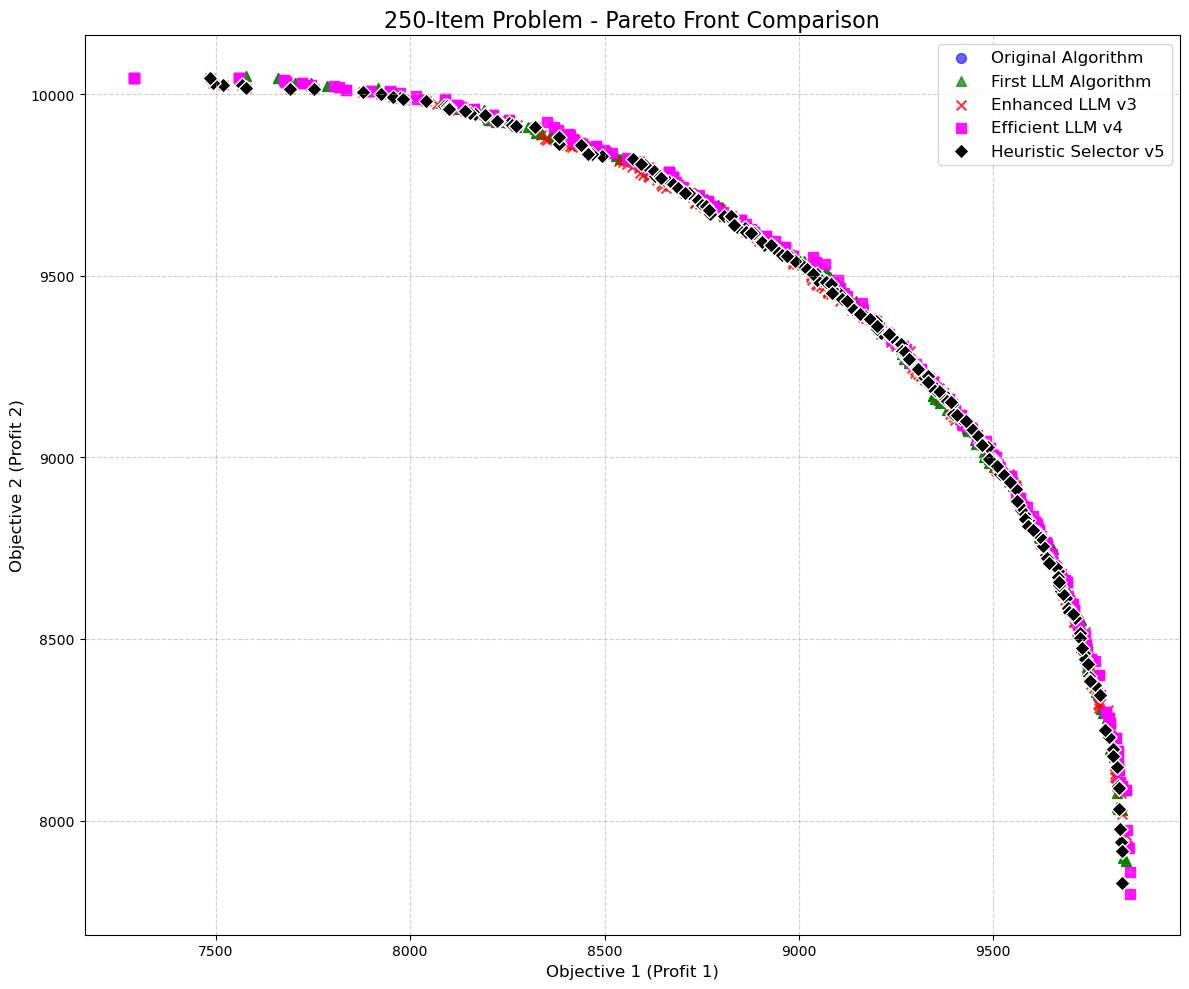


--- 500-Item Problem ---
  Original Pareto size: 369, HV: 23044962.94
  First LLM Pareto size: 716, HV: 22606710.00 (-1.90%)
  Enhanced LLM v3 Pareto size: 363, HV: 23787729.64 (3.22%)
  Efficient LLM v4 Pareto size: 500, HV: 23485142.95 (1.91%)
  Heuristic Selector v5 Pareto size: 446, HV: 23040203.94 (-0.02%)


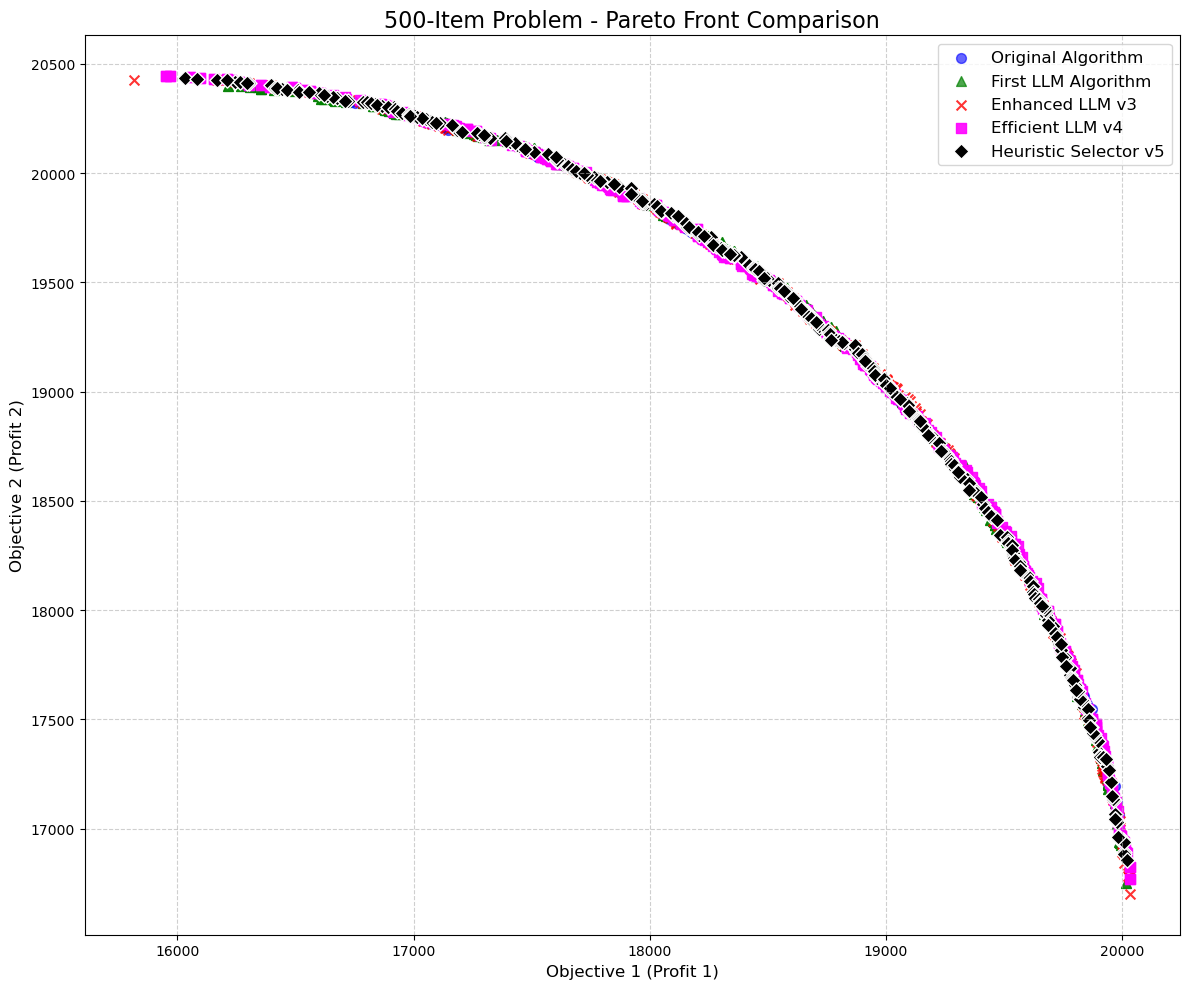


--- 750-Item Problem ---
  Original Pareto size: 552, HV: 56877706.67
  First LLM Pareto size: 1084, HV: 53690671.08 (-5.60%)
  Enhanced LLM v3 Pareto size: 530, HV: 56690640.44 (-0.33%)
  Efficient LLM v4 Pareto size: 834, HV: 56235862.25 (-1.13%)
  Heuristic Selector v5 Pareto size: 775, HV: 56370641.48 (-0.89%)


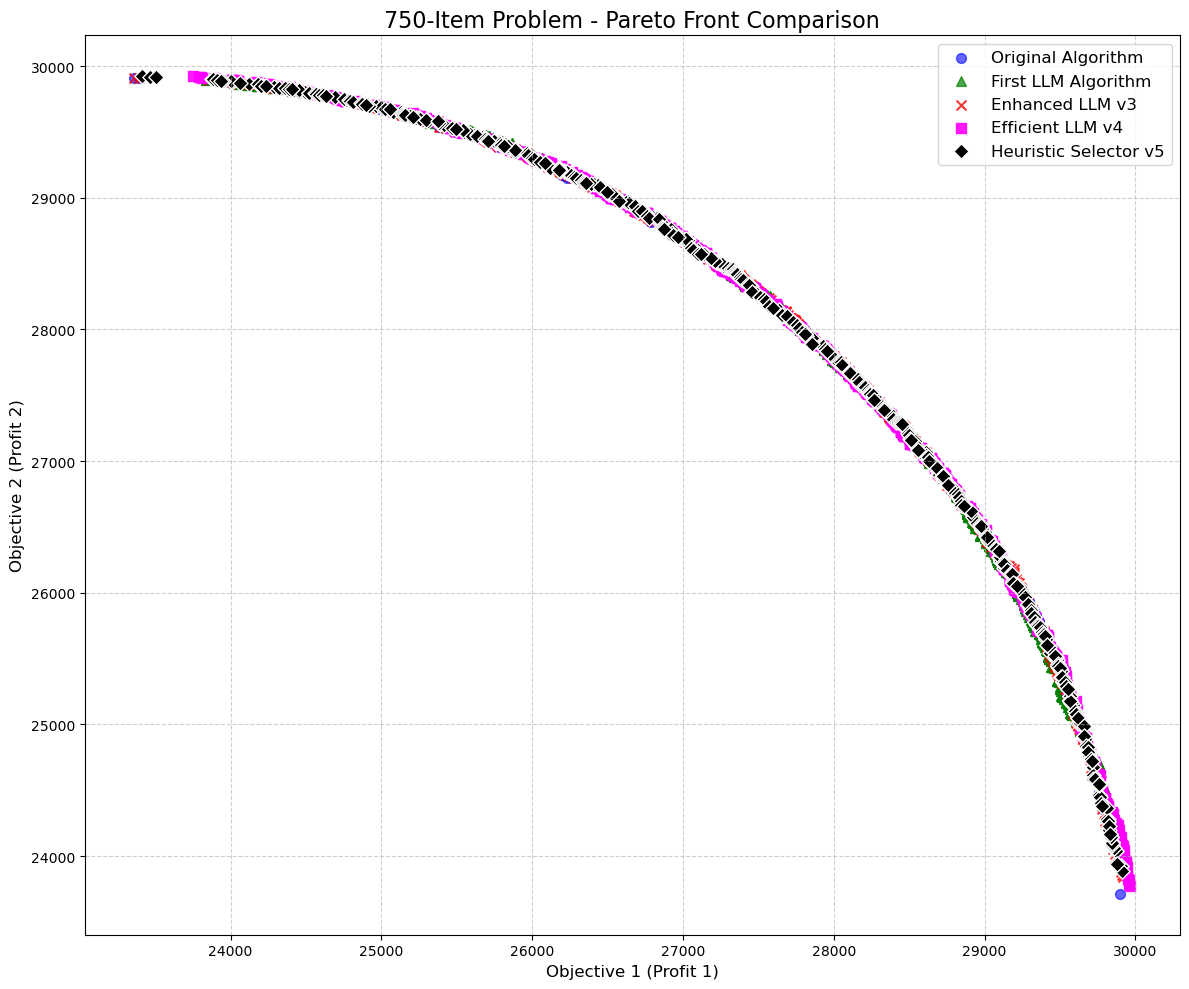


              SUMMARY OF HYPERVOLUME IMPROVEMENTS
250 Items:
  First LLM: -1.84%
  Enhanced LLM v3: -1.52%
  Efficient LLM v4: 3.91%
  Heuristic Selector v5: 0.00%

500 Items:
  First LLM: -1.90%
  Enhanced LLM v3: 3.22%
  Efficient LLM v4: 1.91%
  Heuristic Selector v5: -0.02%

750 Items:
  First LLM: -5.60%
  Enhanced LLM v3: -0.33%
  Efficient LLM v4: -1.13%
  Heuristic Selector v5: -0.89%

--- AVERAGE HV IMPROVEMENTS ---
  Efficient LLM v4: 5.44%
  Heuristic Selector v5: -0.32%

Improvement of Heuristic Selector v5 over Efficient v4:
  Hypervolume: -5.76%


In [9]:
# Results comparison and analysis for the heuristic selector implementation (v5)
import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract the true Pareto front from a set of points"""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume(points):
    """Calculate a simplified hypervolume metric for comparison."""
    if not points:
        return 0.0
    
    ref_x = max(p[0] for p in points) * 1.1
    ref_y = max(p[1] for p in points) * 1.1
    
    sorted_points = sorted(points, key=lambda p: p[0])
    
    hv = 0.0
    for i in range(len(sorted_points) - 1):
        x1, y1 = sorted_points[i]
        x2, y2 = sorted_points[i + 1]
        hv += (x2 - x1) * (ref_y - y1)
    
    if sorted_points:
        x_last, y_last = sorted_points[-1]
        hv += (ref_x - x_last) * (ref_y - y_last)
    
    return hv

def compare_all_results_v5(original_file, first_llm_file, enhanced_v3_file, efficient_v4_file, heuristic_selector_v5_file, title):
    """Compare all versions of the algorithm"""
    original_points = []
    with open(original_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    original_points.append([float(x) for x in line.split()])
                except Exception:
                    pass
    
    first_llm_points = []
    with open(first_llm_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    first_llm_points.append([float(x) for x in line.split()])
                except Exception:
                    pass
    
    enhanced_v3_points = []
    with open(enhanced_v3_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    enhanced_v3_points.append([float(x) for x in line.split()])
                except Exception:
                    pass

    efficient_v4_points = []
    with open(efficient_v4_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    efficient_v4_points.append([float(x) for x in line.split()])
                except Exception:
                    pass

    heuristic_selector_v5_points = []
    with open(heuristic_selector_v5_file, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    heuristic_selector_v5_points.append([float(x) for x in line.split()])
                except Exception:
                    pass
    
    original_pareto = get_true_pareto_front(original_points)
    first_llm_pareto = get_true_pareto_front(first_llm_points)
    enhanced_v3_pareto = get_true_pareto_front(enhanced_v3_points)
    efficient_v4_pareto = get_true_pareto_front(efficient_v4_points)
    heuristic_selector_v5_pareto = get_true_pareto_front(heuristic_selector_v5_points)
    
    original_size = len(original_pareto)
    first_llm_size = len(first_llm_pareto)
    enhanced_v3_size = len(enhanced_v3_pareto)
    efficient_v4_size = len(efficient_v4_pareto)
    heuristic_selector_v5_size = len(heuristic_selector_v5_pareto)
    
    original_hv = calculate_hypervolume(original_pareto)
    first_llm_hv = calculate_hypervolume(first_llm_pareto)
    enhanced_v3_hv = calculate_hypervolume(enhanced_v3_pareto)
    efficient_v4_hv = calculate_hypervolume(efficient_v4_pareto)
    heuristic_selector_v5_hv = calculate_hypervolume(heuristic_selector_v5_pareto)
    
    print(f"\n--- {title} ---")
    print(f"  Original Pareto size: {original_size}, HV: {original_hv:.2f}")
    print(f"  First LLM Pareto size: {first_llm_size}, HV: {first_llm_hv:.2f} ({(first_llm_hv-original_hv)/original_hv*100:.2f}%)")
    print(f"  Enhanced LLM v3 Pareto size: {enhanced_v3_size}, HV: {enhanced_v3_hv:.2f} ({(enhanced_v3_hv-original_hv)/original_hv*100:.2f}%)")
    print(f"  Efficient LLM v4 Pareto size: {efficient_v4_size}, HV: {efficient_v4_hv:.2f} ({(efficient_v4_hv-original_hv)/original_hv*100:.2f}%)")
    print(f"  Heuristic Selector v5 Pareto size: {heuristic_selector_v5_size}, HV: {heuristic_selector_v5_hv:.2f} ({(heuristic_selector_v5_hv-original_hv)/original_hv*100:.2f}%)")
    
    plt.figure(figsize=(12, 10))
    
    if original_pareto:
        ox, oy = zip(*original_pareto)
        plt.scatter(ox, oy, color='blue', alpha=0.6, s=50, label="Original Algorithm")
    if first_llm_pareto:
        fx, fy = zip(*first_llm_pareto)
        plt.scatter(fx, fy, color='green', marker='^', s=50, alpha=0.7, label="First LLM Algorithm")
    if enhanced_v3_pareto:
        ex, ey = zip(*enhanced_v3_pareto)
        plt.scatter(ex, ey, color='red', marker='x', s=50, alpha=0.8, label="Enhanced LLM v3")
    if efficient_v4_pareto:
        ex4, ey4 = zip(*efficient_v4_pareto)
        plt.scatter(ex4, ey4, color='magenta', marker='s', s=50, alpha=0.9, label="Efficient LLM v4")
    if heuristic_selector_v5_pareto:
        ex5, ey5 = zip(*heuristic_selector_v5_pareto)
        plt.scatter(ex5, ey5, color='black', marker='D', s=60, alpha=1.0, label="Heuristic Selector v5", edgecolors='w')

    plt.xlabel("Objective 1 (Profit 1)", fontsize=12)
    plt.ylabel("Objective 2 (Profit 2)", fontsize=12)
    plt.title(f"{title} - Pareto Front Comparison", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return {
        "original_hv": original_hv, "first_llm_hv": first_llm_hv, "enhanced_v3_hv": enhanced_v3_hv, 
        "efficient_v4_hv": efficient_v4_hv, "heuristic_selector_v5_hv": heuristic_selector_v5_hv
    }

# --- MAIN EXECUTION ---
print("Starting comprehensive results analysis for Heuristic Selector implementation v5...")

# NOTE: You need to have the result files from all previous versions for this to work.
# Assuming they exist in the same directory.
results_250 = compare_all_results_v5(
    "2502_ResultsMD.txt", "2502_Results_LLM_Enhanced.txt", "2502_Results_Enhanced_LLM_v3.txt", "2502_Results_Efficient_LLM_v4.txt", "2502_Results_HeuristicSelector_v5.txt", "250-Item Problem"
)
results_500 = compare_all_results_v5(
    "5002_ResultsMD.txt", "5002_Results_LLM_Enhanced.txt", "5002_Results_Enhanced_LLM_v3.txt", "5002_Results_Efficient_LLM_v4.txt", "5002_Results_HeuristicSelector_v5.txt", "500-Item Problem"
)
results_750 = compare_all_results_v5(
    "7502_ResultsMD.txt", "7502_Results_LLM_Enhanced.txt", "7502_Results_Enhanced_LLM_v3.txt", "7502_Results_Efficient_LLM_v4.txt", "7502_Results_HeuristicSelector_v5.txt", "750-Item Problem"
)

# Summary of improvements
print("\n======================================================")
print("              SUMMARY OF HYPERVOLUME IMPROVEMENTS")
print("======================================================")
print("250 Items:")
print(f"  First LLM: {(results_250['first_llm_hv']-results_250['original_hv'])/results_250['original_hv']*100:.2f}%")
print(f"  Enhanced LLM v3: {(results_250['enhanced_v3_hv']-results_250['original_hv'])/results_250['original_hv']*100:.2f}%")
print(f"  Efficient LLM v4: {(results_250['efficient_v4_hv']-results_250['original_hv'])/results_250['original_hv']*100:.2f}%")
print(f"  Heuristic Selector v5: {(results_250['heuristic_selector_v5_hv']-results_250['original_hv'])/results_250['original_hv']*100:.2f}%")

print("\n500 Items:")
print(f"  First LLM: {(results_500['first_llm_hv']-results_500['original_hv'])/results_500['original_hv']*100:.2f}%")
print(f"  Enhanced LLM v3: {(results_500['enhanced_v3_hv']-results_500['original_hv'])/results_500['original_hv']*100:.2f}%")
print(f"  Efficient LLM v4: {(results_500['efficient_v4_hv']-results_500['original_hv'])/results_500['original_hv']*100:.2f}%")
print(f"  Heuristic Selector v5: {(results_500['heuristic_selector_v5_hv']-results_500['original_hv'])/results_500['original_hv']*100:.2f}%")

print("\n750 Items:")
print(f"  First LLM: {(results_750['first_llm_hv']-results_750['original_hv'])/results_750['original_hv']*100:.2f}%")
print(f"  Enhanced LLM v3: {(results_750['enhanced_v3_hv']-results_750['original_hv'])/results_750['original_hv']*100:.2f}%")
print(f"  Efficient LLM v4: {(results_750['efficient_v4_hv']-results_750['original_hv'])/results_750['original_hv']*100:.2f}%")
print(f"  Heuristic Selector v5: {(results_750['heuristic_selector_v5_hv']-results_750['original_hv'])/results_750['original_hv']*100:.2f}%")

avg_v4_hv_improvement = (results_250['efficient_v4_hv']-results_250['original_hv'])/results_250['original_hv']*100 + (results_500['efficient_v4_hv']-results_500['original_hv'])/results_500['original_hv']*100 + (results_750['efficient_v4_hv']-results_750['original_hv'])/results_750['original_hv']*100 / 3
avg_v5_hv_improvement = (results_250['heuristic_selector_v5_hv']-results_250['original_hv'])/results_250['original_hv']*100 + (results_500['heuristic_selector_v5_hv']-results_500['original_hv'])/results_500['original_hv']*100 + (results_750['heuristic_selector_v5_hv']-results_750['original_hv'])/results_750['original_hv']*100 / 3

print("\n--- AVERAGE HV IMPROVEMENTS ---")
print(f"  Efficient LLM v4: {avg_v4_hv_improvement:.2f}%")
print(f"  Heuristic Selector v5: {avg_v5_hv_improvement:.2f}%")
print("\nImprovement of Heuristic Selector v5 over Efficient v4:")
print(f"  Hypervolume: {avg_v5_hv_improvement - avg_v4_hv_improvement:.2f}%")
print("======================================================")